# Model Interpretability

In [1]:
import os
from datetime import datetime
from io import BytesIO
from pathlib import Path

import boto3
import botocore.exceptions
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from dotenv import load_dotenv
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
_ = shap.initjs()

In [3]:
PROJ_ROOT = Path.cwd().parent

In [4]:
assert load_dotenv(dotenv_path=PROJ_ROOT.parent / ".env")

In [5]:
import cc_churn.explanation as shexp
import cc_churn.visualization as vzu
import r2.io_utils as r2io
from cc_churn.transformers import CategoryCombiner
from utils.df_utils import show_df

## About

Provide model interpredation for predicted churners and non-churners, among all available customers' data.

## User Inputs

In [6]:
# R2 data bucket details
# # name of train data key (file) in private R2 bucket
r2_key_train = "train_data.parquet.gzip"
# # name of validation data key (file) in private R2 bucket
r2_key_val = "validation_data.parquet.gzip"
# # name of test data key (file) in private R2 bucket
r2_key_test = "test_data.parquet.gzip"

# datatypes for categorical and ordinal columns
dtypes_ordinals = {
    "gender": "string[pyarrow]",
    "income_category": "string[pyarrow]",
    "education_level": "string[pyarrow]",
}
dtypes_categoricals = {
    "marital_status": "category",
    "card_category": "category",
}

dtypes_transformed = {
    # change dtype for identifier features, but these will be dropped later
    "clientnum": "int32[pyarrow]",
    # categorical features
    "gender": "category",
    # # change dtype for card_category, but it will be dropped later
    "card_category": "category",
    "marital_status": "category",
    # # change original integer to category for dependent_count
    "dependent_count": "category",
    # ordinal features
    "education_level": "string[pyarrow]",
    "income_category": "string[pyarrow]",
    # numerical features
    "customer_age": "int8[pyarrow]",
    "months_on_book": "int16[pyarrow]",
    "num_products": "int16[pyarrow]",
    "months_inactive_12_mon": "int16[pyarrow]",
    "contacts_count_12_mon": "int16[pyarrow]",
    "credit_limit": "double[pyarrow]",
    "total_revolv_bal": "double[pyarrow]",
    "avg_open_to_buy": "double[pyarrow]",
    "total_amt_chng_q4_q1": "double[pyarrow]",
    "total_trans_amt": "double[pyarrow]",
    "total_trans_ct": "int16[pyarrow]",
    "total_ct_chng_q4_q1": "double[pyarrow]",
    "avg_utilization_ratio": "double[pyarrow]",
}

# trained model prefix
key_prefix = "2026-04-02/best_model__"

# predictions prefix
r2_key_pred = "2026-04-02/all_predictions__"
cols_predictions = ["clientnum", "y_pred", "y_pred_proba"]

label = "is_churned"

In [7]:
account_id = os.getenv("ACCOUNT_ID")
access_key_id = os.getenv("ACCESS_KEY_ID_USER2")
secret_access_key = os.getenv("SECRET_ACCESS_KEY_USER2")
bucket_name = os.getenv("BUCKET_NAME")

s3_client = boto3.client(
    "s3",
    endpoint_url=f"https://{account_id}.r2.cloudflarestorage.com",
    aws_access_key_id=access_key_id,
    aws_secret_access_key=secret_access_key,
    region_name="auto",
)

## Load Data

### Trained Model

Load pipeline

In [8]:
%%time
pipe_best = r2io.joblib_load_from_r2(s3_client, bucket_name, key_prefix)
pipe_best

CPU times: user 65.8 ms, sys: 21.8 ms, total: 87.6 ms
Wall time: 306 ms


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,th

Get the best features, that were also preprocessed by the best pipeline (`pipe_best`) above

In [9]:
best_features = (
    pipe_best.named_steps["pre"]
    .named_transformers_["num"]
    .feature_names_in_.tolist()
)

### Predictions

Load predictions for each customer in all available data

In [10]:
%%time
df_all_pred = r2io.pandas_read_filtered_parquets_r2(
    s3_client, bucket_name, r2_key_pred, cols_predictions
)

_ = show_df(df_all_pred)
with pd.option_context('display.max_columns', None):
    display(df_all_pred.head(1))

,num_missing,num_unique,dtype
clientnum,0,10127,int32[pyarrow]
y_pred,0,2,int16[pyarrow]
y_pred_proba,0,9353,double[pyarrow]


Shape: 10,127 rows X 3 columns, Memory Usage: 144.442 KB


,clientnum,y_pred,y_pred_proba
0,714283458,0,0.006174


CPU times: user 64.2 ms, sys: 5.83 ms, total: 70 ms
Wall time: 210 ms


### Data

Load the training, validation and test data and combine

In [11]:
%%time
df_train = (
    r2io.pandas_read_parquet_r2(s3_client, bucket_name, r2_key_train)
    .astype(dtypes_ordinals)
    .astype(dtypes_categoricals)
)
df_val = (
    r2io.pandas_read_parquet_r2(s3_client, bucket_name, r2_key_val)
    .astype(dtypes_ordinals)
    .astype(dtypes_categoricals)
)
df_test = (
    r2io.pandas_read_parquet_r2(s3_client, bucket_name, r2_key_test)
    .astype(dtypes_ordinals)
    .astype(dtypes_categoricals)
)

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f"Obtained {len(df_all):,} rows of all available data")

_ = show_df(df_all)
with pd.option_context('display.max_columns', None):
    display(df_all.head(1))

Obtained 10,127 rows of all available data


,num_missing,num_unique,dtype
clientnum,0,10127,int32[pyarrow]
is_churned,0,2,int8[pyarrow]
customer_age,0,45,int8[pyarrow]
gender,0,2,string
dependent_count,0,6,int8[pyarrow]
education_level,0,7,string
marital_status,0,4,category
income_category,0,6,string
card_category,0,4,category
months_on_book,0,44,int16[pyarrow]


Shape: 10,127 rows X 21 columns, Memory Usage: 1229.837 KB


,clientnum,is_churned,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,num_products,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolv_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,714283458,0,40,M,2,College,Single,$80K - $120K,Blue,36,5,1,4,14544.0,0.0,14544.0,0.768,4064.0,92,0.769,0.0


CPU times: user 110 ms, sys: 7.83 ms, total: 118 ms
Wall time: 298 ms


## Separate Features from Target

In [12]:
X_all = df_all.drop(columns=[label])
y_all = df_all[label]

Get the features that were not used in training for the best pipeline above

In [13]:
features_non_preprocessed = list(set(list(X_all)) - set(best_features))

## Transform Data

### Non-Numerical Features with Rare Categories

Below is the same `scikit-learn` `ColumnTransformer` that uses a custom transformer `CategoryCombiner` to combine the categories for a subset of the ordinal and categorical features

In [14]:
categorical_ordinal_grouping_transformer = ColumnTransformer(
    [
        (
            "combine_income_category",
            CategoryCombiner(["$80K - $120K", "$120K +"], "$80K+"),
            ["income_category"],
        ),
        (
            "combine_education_level",
            CategoryCombiner(["Post-Graduate", "Doctorate"], "Post-Graduate"),
            ["education_level"],
        ),
        (
            "combine_marital_status",
            CategoryCombiner(["Unknown", "Divorced"], "Other"),
            ["marital_status"],
        ),
        (
            "combine_dependent_count",
            CategoryCombiner(["4", "5"], "4+"),
            ["dependent_count"],
        ),
    ],
    remainder="passthrough",
)
pipe_cat_ord_transformer = Pipeline(
    [("grouping", categorical_ordinal_grouping_transformer)]
)

mapper_grouping_transformer = {
    # convert category dtype to string for grouping
    "marital_status": "string[pyarrow]",
    # convert integer dtype to string for grouping
    "dependent_count": "string[pyarrow]",
}

This custom category combining transformer is applied below to all data

In [15]:
# train custom transformer
_ = pipe_cat_ord_transformer.fit(X_all.astype(mapper_grouping_transformer))

# use trained transfromer to get transformed column names
columns_transformed = list(
    map(
        lambda x: x.split("__")[1],
        (
            pipe_cat_ord_transformer.get_feature_names_out(
                input_features=list(X_all)
            ).tolist()
        ),
    )
)

# apply trained transformer to perform category grouping on all data
X_all = pd.DataFrame(
    pipe_cat_ord_transformer.transform(
        X_all.astype(mapper_grouping_transformer)
    ),
    columns=columns_transformed,
    index=X_all.index,
).astype(dtypes_transformed)

### Pre-Process Numerical Features

Get the preprocessor step from the best pipeline

In [16]:
preprocessor = pipe_best.named_steps["pre"]
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name

Use the best pre-processor to pre-process all numerical features

In [17]:
%%time
_ = preprocessor.fit(X_all[best_features])
columns_transformed = (
    preprocessor.named_transformers_["num"].get_feature_names_out().tolist()
)
X_all_best_features_pre = pd.DataFrame(
    preprocessor.transform(X_all[best_features]),
    columns=columns_transformed,
    index=X_all.index,
)

CPU times: user 22.2 ms, sys: 11 ms, total: 33.2 ms
Wall time: 2.32 s


Combine non-pre processed features, pre-processed numerical features and the true label for all customers

In [18]:
df_all_pre = pd.concat(
    [
        X_all[features_non_preprocessed],
        X_all_best_features_pre,
        y_all.rename("y"),
    ],
    axis=1,
).merge(df_all_pred, on=["clientnum"], how="left")
df_all_pre

,avg_utilization_ratio,clientnum,education_level,avg_open_to_buy,income_category,gender,dependent_count,marital_status,card_category,customer_age,...,contacts_count_12_mon,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,credit_limit,total_revolv_bal,y,y_pred,y_pred_proba
0,0.0,714283458,College,14544.0,$80K+,M,2,Single,Blue,0.297872,...,0.666667,0.226082,0.197730,0.635659,0.207054,0.396210,0.000000,0,0,0.006174
1,0.665,787587033,Graduate,1004.0,Less than $40K,F,4+,Single,Blue,0.340426,...,0.333333,0.279070,0.219929,0.596899,0.199246,0.047092,0.791418,0,0,0.004301
2,0.722,714672933,Graduate,875.0,$40K - $60K,F,3,Married,Blue,0.553191,...,0.333333,0.235796,0.217370,0.573643,0.183091,0.051536,0.901073,0,0,0.006487
3,0.758,714974658,College,597.0,Less than $40K,F,4+,Married,Blue,0.468085,...,0.666667,0.176626,0.039446,0.193798,0.358912,0.031009,0.741756,0,0,0.019542
4,0.636,712049208,Post-Graduate,1438.0,$60K - $80K,M,3,Married,Blue,0.638298,...,0.333333,0.142479,0.040503,0.116279,0.291599,0.076084,1.000000,0,0,0.044123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,0.0,817247658,High School,21317.0,$60K - $80K,M,3,Other,Blue,0.404255,...,0.500000,0.245216,0.183821,0.441860,0.277329,0.600970,0.000000,0,0,0.026651
10123,0.022,816834933,Graduate,30029.0,Unknown,F,4+,Single,Silver,0.170213,...,0.333333,0.212246,0.119172,0.418605,0.141088,0.884696,0.267382,0,0,0.138303
10124,0.589,790221633,Graduate,1601.0,$40K - $60K,F,4+,Single,Blue,0.382979,...,0.500000,0.219606,0.229053,0.519380,0.212978,0.074331,0.912197,0,0,0.013666
10125,0.334,719535558,College,3712.0,$40K - $60K,M,4+,Other,Blue,0.446809,...,0.166667,0.230497,0.201346,0.480620,0.171244,0.124909,0.738180,0,0,0.003843


## Model Interpretability

### Predicted Churners

Get SHAP values (`shap_values`) and SHAP explanation object (`shap_explainer_values_*`) for the predicted churners

In [19]:
%%time
_, shap_explainer_values_pc = shexp.get_shap_values(
    pipe_best.named_steps['clf'], df_all_pre.query("y_pred == 1")[best_features]
)

CPU times: user 166 ms, sys: 27 μs, total: 166 ms
Wall time: 166 ms


Plot SHAP summary subplots consisting of

1. (LHS) [beeswarm plot](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/beeswarm.html#A-simple-beeswarm-summary-plot) that shows how the most important features impact the model's predictions for churners
2. (RHS) [bar plot](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html#Global-bar-plot) showing the global feature importance, across all predicted churners

CPU times: user 101 ms, sys: 1.87 ms, total: 102 ms
Wall time: 102 ms


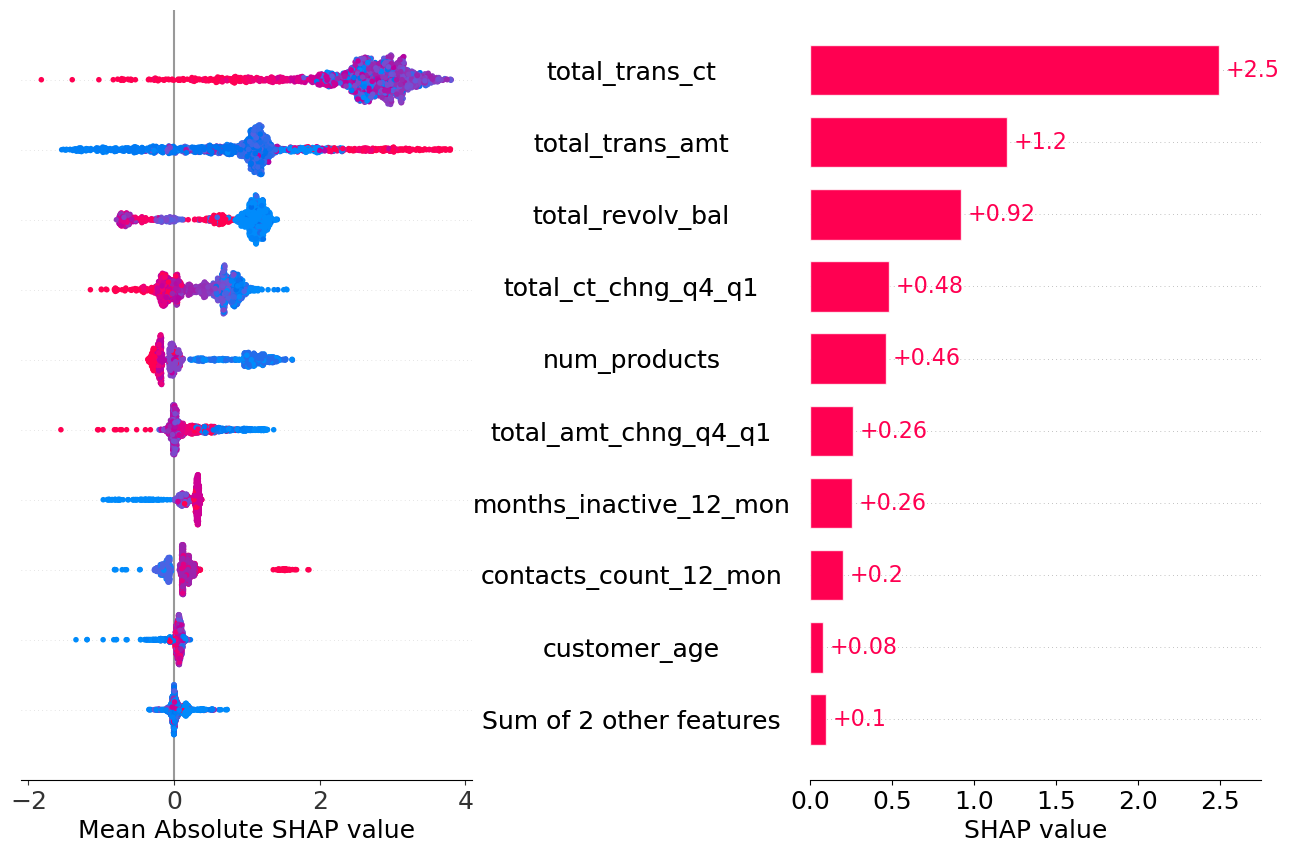

In [20]:
%%time
vzu.plot_shap_summary_plots(
    shap_explainer_values_pc,
    y_axis_annot_offset=0,
    axis_label_fontsize=18,
    y_axis_annot_fontsize=16,
    wspace=0.75,
    fig_size=(16, 10),
)

The width of the bars in the bar plot (left) indicates the importance of the features to the best model's predictions. Bar width is calculated as the average of the absolute value of the individual SHAP values for all predicted churners (customers predicted to cancel their credit card services at the bank).

The beeswarm plot (right) indicates the directionality of the individual contribution to model predictions by each feature: red indicates a higher contribution while blue indicates a lower contribution ([link](https://www.researchgate.net/publication/359141623_Prediction_of_hearing_recovery_in_unilateral_sudden_sensorineural_hearing_loss_using_artificial_intelligence)). It indicates how the most important features impact the model's predictions for churners. The order of features is based on the average of the absolute value of SHAP values for each feature and so it places more emphasis on broad average impact across all predicted churners.

### Predicted Non-Churners

Get the global SHAP values and SHAP explanation object for the predicted non-churners

In [21]:
%%time
_, shap_explainer_values_pnc = shexp.get_shap_values(
    pipe_best.named_steps['clf'], df_all_pre.query("y_pred == 0")[best_features]
)

CPU times: user 726 ms, sys: 1 ms, total: 727 ms
Wall time: 726 ms


Plot SHAP summary subplots

CPU times: user 138 ms, sys: 1.09 ms, total: 139 ms
Wall time: 139 ms


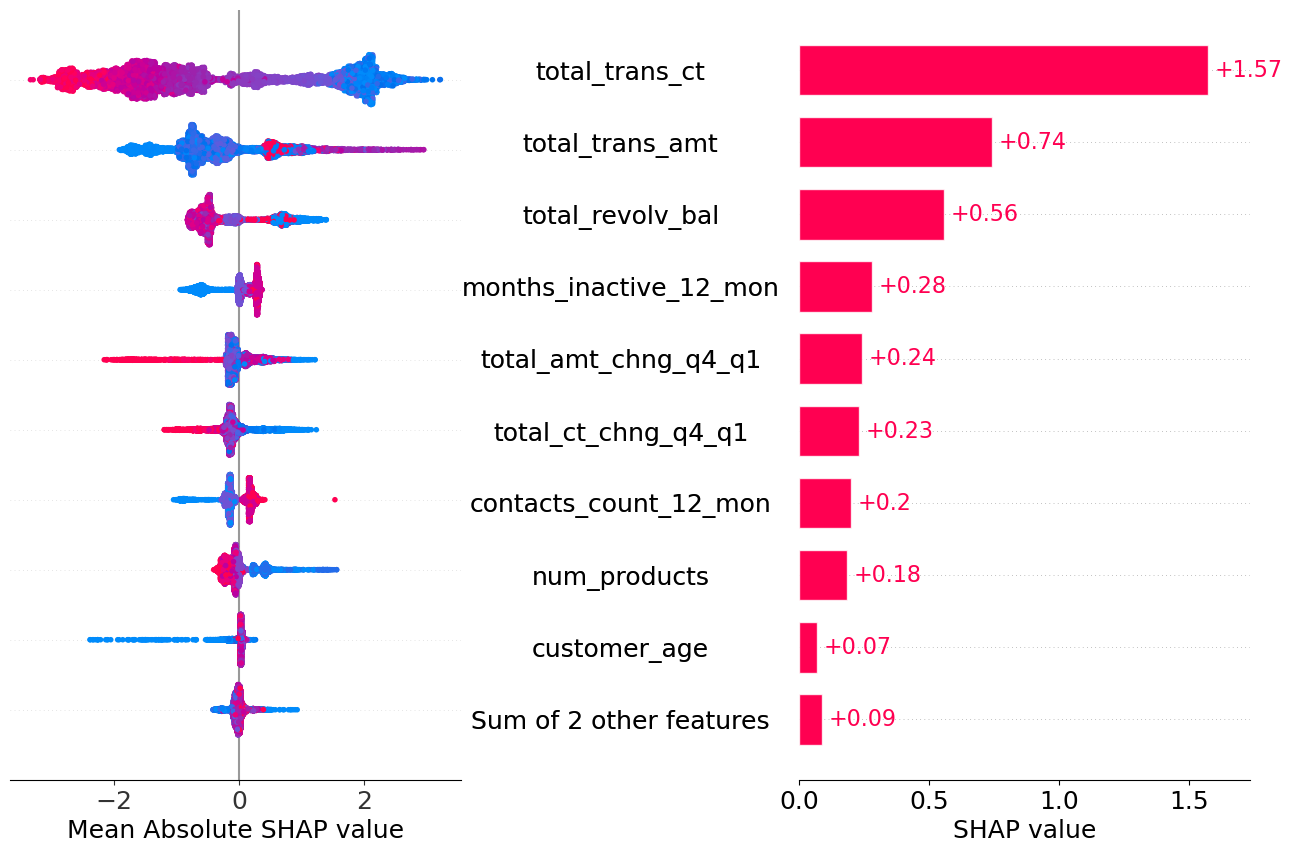

In [22]:
%%time
vzu.plot_shap_summary_plots(
    shap_explainer_values_pnc,
    y_axis_annot_offset=0,
    axis_label_fontsize=18,
    y_axis_annot_fontsize=16,
    wspace=0.75,
    fig_size=(16, 10),
)